# Plot parcellated features on a brain surface

In [ ]:
!pip install nilearn
!pip install nibabel
!pip install brainspace
!pip install seaborn

In [1]:
import os
import tempfile
import requests
import numpy as np
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt

from nilearn import plotting, datasets
from brainspace.utils.parcellation import map_to_labels

In [2]:
def fetch_annot(atlas, surf='fsaverage5'):
    '''
      Fetches the annotation labels for a specific brain parcellation and generates a medial wall mask.

      Parameters:
      -----------
      atlas : str
        The name of the brain parcellation atlas to fetch (e.g., 'glasser-360', 'aparc-a2009s').
      surf : str, optional
        The surface space to use for the parcellation. Default is 'fsaverage5'.
        Options:
        - 'fsaverage5': Uses FreeSurfer's fsaverage5 surface space.
        - 'fsLR-32k': Uses fsLR-32k surface space.

      Returns:
      --------
      labels : numpy.ndarray
        An array of labels corresponding to the parcellation, with medial wall regions set to 0.
      mask : numpy.ndarray
        A boolean mask indicating non-medial wall regions (True for valid regions, False for medial wall).
      Ndim : int
        The number of unique labels in the parcellation.

      Notes:
      ------
      - The function downloads the required annotation files from a GitHub repository.
      - For 'fsaverage5', it processes both left and right hemisphere annotation files.
      - For 'fsLR-32k', it reads the labels from a CSV file.
      - Medial wall regions are excluded from the mask.
      - For the 'aparc-a2009s' atlas on 'fsaverage5', specific medial wall labels (lh=42, rh=117) are excluded.

      Raises:
      -------
      Exception
        If the annotation file cannot be downloaded or the request fails.

      Example:
      --------
      labels, mask, Ndim = fetch_annot('glasser-360', surf='fsaverage5')
    '''

    # Construct the URL for the surface file on GitHub
    url = f'https://github.com/MICA-MNI/micapipe/raw/refs/heads/master/parcellations'
      
    def download_atlas(url_to_file):
      # Download the surface file from the URL
      response = requests.get(url_to_file)

      # Ensure the request was successful
      if response.status_code != 200:
        raise Exception(f"Failed to download the {atlas} atlas on {surf} (Status code: {response.status_code})\n{url_to_file}")

      # Step 2: Save the downloaded file in a temporary directory
      with tempfile.NamedTemporaryFile(delete=False) as temp_file:
        temp_file.write(response.content)
        temp_file_name = temp_file.name  # Get the temporary file name
      
      return(temp_file_name)
    
    if surf == 'fsaverage5':
        # Load LEFT annotation file in fsaverage5
        tmp_file  = download_atlas(f'{url}/lh.{atlas}_mics.annot')
        annot_lh_fs5= nib.freesurfer.read_annot(tmp_file)
        os.remove(tmp_file)

        # Unique number of labels of a given atlas
        Ndim = max(np.unique(annot_lh_fs5[0]))

        # Load RIGHT annotation file in fsaverage5
        tmp_file  = download_atlas(f'{url}/rh.{atlas}_mics.annot')
        print(tmp_file)
        annot_rh_fs5 = nib.freesurfer.read_annot(tmp_file)[0]+Ndim
        os.remove(tmp_file)

        # replace with 0 the medial wall of the right labels
        annot_rh_fs5 = np.where(annot_rh_fs5==Ndim, 0, annot_rh_fs5) 

        # fsaverage5 labels
        labels = np.concatenate((annot_lh_fs5[0], annot_rh_fs5), axis=0)
    
    else:
        # Read label for fsLR-32k
        tmp_file  = download_atlas(f'{url}/{atlas}_conte69.csv')
        labels = np.loadtxt(open(tmp_file), dtype=int)
        os.remove(tmp_file)

    # mask of the medial wall
    mask = labels != 0
    
    # Midwall labels of aparc-a2009s are lh=42 and rh=117
    if atlas == 'aparc-a2009s' and surf == 'fsaverage5':
        mask[(labels == 117) | (labels == 42)] = 0
    
    #print(f'{atlas}; midwall = {Ndim}, length = {str(labels.shape)}')
    
    return(labels, mask, Ndim)

## Fetch the labels and surfaces

In [3]:
# Load annotation file
annot = 'glasser-360'
labels, mask, Ndim = fetch_annot(annot, surf='fsaverage5')

# Load the Glasser Look Up Table (LUT)
# glasser = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')

# This is the brain's surface mesh (you can use 'inflated' or 'white' too)
surf_mesh = datasets.fetch_surf_fsaverage('fsaverage5')

# For example, use 'inflated' surface to show the brain's cortical surface
left_surf_mesh = surf_mesh['infl_left']
right_surf_mesh = surf_mesh['infl_right']


/var/folders/yv/7rdtqnkn0mb58f5x_yprm2gw0000gn/T/tmp37e0rqv0


In [4]:
# Get the Binary degree centrality into a numpy array
# matrix_centrality = np.sum(adj_matrix, axis=1, dtype=float)

# Random matrix for testing with the same length as the number of parcels
matrix_centrality = np.random.rand(360)

# Map the feature from parcels to vertices
feat_fsaverage5 = map_to_labels(matrix_centrality, labels, mask=mask, fill=np.nan)


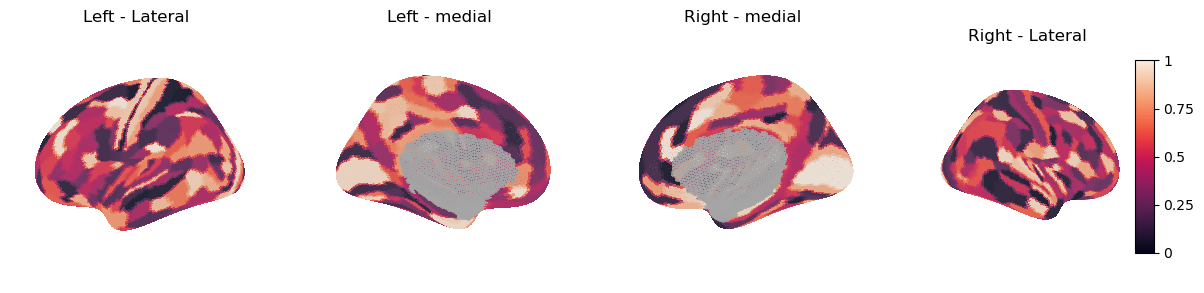

In [5]:
# Create a figure with 1 row and 4 columns
fig, axes = plt.subplots(1, 4, figsize=(15, 5), subplot_kw={'projection': '3d'})

# Left Hemisphere - Lateral View
plotting.plot_surf_stat_map(
    left_surf_mesh, stat_map=feat_fsaverage5[:10242], cmap='rocket', colorbar=False, bg_on_data=True,
    axes=axes[0], hemi='left', view='lateral', title="Left - Lateral")

# Left Hemisphere - Medial View
plotting.plot_surf_stat_map(
    left_surf_mesh, stat_map=feat_fsaverage5[:10242], cmap='rocket', colorbar=False, bg_on_data=True,
    axes=axes[1], hemi='left', view='medial', title="Left - medial")

# Right Hemisphere - Medial View
plotting.plot_surf_stat_map(
    right_surf_mesh, stat_map=feat_fsaverage5[10242:], cmap='rocket', colorbar=False, bg_on_data=True,
    axes=axes[2], hemi='right', view='medial', title="Right - medial")

# Right Hemisphere - Lateral View (With Colorbar)
plotting.plot_surf_stat_map(
    right_surf_mesh, stat_map=feat_fsaverage5[10242:], cmap='rocket', colorbar=True, bg_on_data=True,
    axes=axes[3], hemi='right', view='lateral', title="Right - Lateral", vmin=0, vmax=1)

# Show the plots
plt.show()